In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducibility

n = 500
engine_size = np.random.uniform(1.0, 5.0, n)
horsepower  = 60 + engine_size * 40 + np.random.normal(0, 15, n)
weight      = 900 + engine_size * 350 + np.random.normal(0, 100, n)
cylinders   = np.clip(np.round(engine_size * 1.6), 3, 12)

mpg = 45 - engine_size*4 - weight*0.005 - horsepower*0.03 + np.random.normal(0, 1.5, n)
mpg = np.clip(mpg, 8, 45)

car_df = pd.DataFrame({
    "engine_size_L": engine_size, "horsepower": horsepower,
    "weight_kg": weight, "cylinders": cylinders, "mpg": mpg
})

car_df.head()

,engine_size_L,horsepower,weight_kg,cylinders,mpg
0,2.498160,165.052759,1832.748985,4.0,22.844642
1,4.802857,280.256852,2545.070820,8.0,8.000000
2,3.927976,231.375388,2333.857002,6.0,10.725556
3,3.394634,187.131803,2198.992236,5.0,13.682422
4,1.624075,111.486762,1550.474315,3.0,28.096686


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = car_df.drop(columns=["mpg"])
y = car_df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

print("Training done. Train set size:", len(X_train), "| Test set size:", len(X_test))

Training done. Train set size: 400 | Test set size: 100


In [ ]:
results = {}

for name, model in [("Linear Regression", lr), ("Random Forest", rf)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")

results_df = pd.DataFrame(results).T.round(3)
results_df

Linear Regression: MAE=1.27  RMSE=1.57  R2=0.962
Random Forest: MAE=1.17  RMSE=1.53  R2=0.963


,MAE,RMSE,R2
Linear Regression,1.271,1.568,0.962
Random Forest,1.171,1.532,0.963


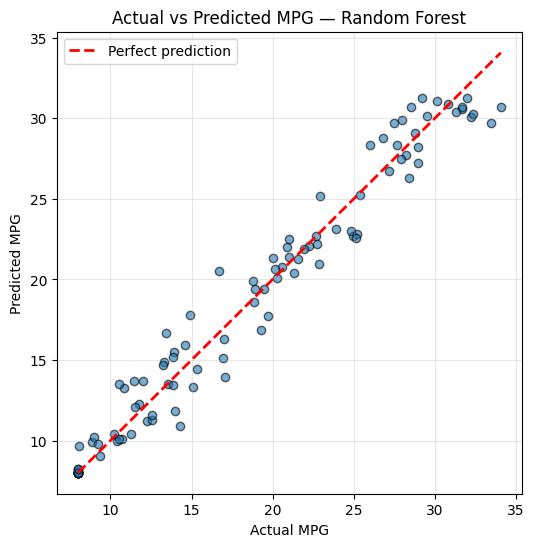

In [ ]:
best_model = rf  # Random Forest performed better
best_name = "Random Forest"
preds = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect prediction")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title(f"Actual vs Predicted MPG — {best_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()